# Определение сорта вина
## Случайный лес

---

**Задача:** по химическому составу вина определить, к какому из трёх
сортов оно относится.

**Тип задачи:** многоклассовая классификация — три сорта вина.

**Алгоритм:** случайный лес (Random Forest) — ансамбль деревьев решений.

**Инструменты:** Python, pandas, scikit-learn, matplotlib, seaborn.

Каждое действие подробно объясняется в комментариях,
чтобы разобраться мог даже человек, который программирует впервые.

## 1. Зависимости

    pandas          — работа с таблицами
    numpy           — математика и массивы чисел
    scikit-learn    — машинное обучение
    matplotlib      — построение графиков
    seaborn         — статистические графики

Если вы запускаете ноутбук в Google Colab, выполните:

    !pip install -q pandas numpy scikit-learn matplotlib seaborn

In [1]:
# ============================================================
# ЯЧЕЙКА ЗАВИСИМОСТЕЙ
# Подключаем всё, что понадобится в этом ноутбуке.
# ============================================================

# pandas — работа с таблицами. Сокращаем до pd.
import pandas as pd

# numpy — математика и массивы чисел. Сокращаем до np.
import numpy as np

# matplotlib.pyplot — рисование графиков. Сокращаем до plt.
import matplotlib.pyplot as plt

# seaborn — статистические графики поверх matplotlib. Сокращаем до sns.
import seaborn as sns

# ------------------------------------------------------------
# Инструменты машинного обучения
# ------------------------------------------------------------

# load_wine — функция загрузки набора данных о вине.
from sklearn.datasets import load_wine

# train_test_split — делит данные на обучающую и тестовую части.
from sklearn.model_selection import train_test_split

# cross_val_score — кросс-валидация: более надёжная оценка качества,
# чем одно разделение на обучение и тест.
from sklearn.model_selection import cross_val_score

# RandomForestClassifier — сама модель случайного леса.
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# Метрики качества классификации
# ------------------------------------------------------------

# accuracy_score — доля правильных ответов.
# confusion_matrix — таблица, показывающая, какие сорта модель путает.
# classification_report — полный отчёт со всеми метриками сразу.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# sklearn целиком — чтобы вывести версию.
import sklearn

# ------------------------------------------------------------
# Настройки графиков
# ------------------------------------------------------------

# Аккуратная тема с белым фоном и сеткой.
sns.set_theme(style="whitegrid")

# Размер графиков по умолчанию.
plt.rcParams["figure.figsize"] = (10, 6)

# Размер базового шрифта.
plt.rcParams["font.size"] = 11

# Не обрезать столбцы таблиц при выводе.
pd.set_option("display.max_columns", None)

# Показывать все строки таблиц, если их немного.
pd.set_option("display.max_rows", 100)

# ------------------------------------------------------------
# Печатаем версии библиотек — важно для воспроизводимости.
# ------------------------------------------------------------
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("scikit-learn :", sklearn.__version__)
print("matplotlib   :", plt.matplotlib.__version__)
print("seaborn      :", sns.__version__)
print()
print("Все библиотеки подключены успешно.")

pandas       : 3.0.5
numpy        : 2.5.3
scikit-learn : 1.9.1
matplotlib   : 3.11.2
seaborn      : 0.13.2

Все библиотеки подключены успешно.


## 2. Описание датасета

**Источник:** набор данных Wine из библиотеки scikit-learn.
Химический анализ вин, выращенных в одном регионе Италии,
но происходящих от трёх разных сортов винограда.

**Размер:** 178 образцов, 13 числовых признаков.

| Признак | Что означает |
|---|---|
| alcohol | содержание алкоголя |
| malic_acid | яблочная кислота |
| ash | зола |
| alcalinity_of_ash | щёлочность золы |
| magnesium | содержание магния |
| total_phenols | общее содержание фенолов |
| flavanoids | флавоноиды |
| nonflavanoid_phenols | нефлавоноидные фенолы |
| proanthocyanins | проантоцианидины |
| color_intensity | интенсивность цвета |
| hue | оттенок цвета |
| od280/od315_of_diluted_wines | оптическая плотность разбавленного вина |
| proline | содержание пролина (аминокислота) |

**Целевая переменная:** сорт вина, три класса.

* **0 = class_0** — 59 образцов;
* **1 = class_1** — 71 образец;
* **2 = class_2** — 48 образцов.

**Обратите внимание:** классы **не сбалансированы** — их 59, 71 и 48.
Поэтому одной метрики accuracy здесь недостаточно: нужно смотреть
precision и recall по каждому сорту отдельно.

## 3. Загрузка данных

In [2]:
# Загружаем датасет. Внутри — признаки, ответы и описания.
wine = load_wine()

# Признаки: превращаем в таблицу pandas с названиями столбцов.
X = pd.DataFrame(wine.data, columns=wine.feature_names)

# Ответы: превращаем в столбец Series с именем "wine_class".
y = pd.Series(wine.target, name="wine_class")

# Печатаем размеры данных.
print("Признаки X :", X.shape)
print("Ответы y   :", y.shape)
print()

# Печатаем названия признаков — всего их 13.
print("Названия признаков:")
for i, name in enumerate(wine.feature_names, start=1):
    print(f"  {i:2d}. {name}")

print()
# Печатаем названия классов.
print("Сорта вина:")
for code_value, name in enumerate(wine.target_names):
    print(f"  {code_value} = {name}")

Признаки X : (178, 13)
Ответы y   : (178,)

Названия признаков:
   1. alcohol
   2. malic_acid
   3. ash
   4. alcalinity_of_ash
   5. magnesium
   6. total_phenols
   7. flavanoids
   8. nonflavanoid_phenols
   9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline

Сорта вина:
  0 = class_0
  1 = class_1
  2 = class_2


In [3]:
# Собираем всё в одну таблицу для удобного анализа.
df = X.copy()
df["wine_class"] = y

# Добавляем столбец с текстовым названием сорта.
# map подставляет название класса по его номеру.
df["wine_name"] = df["wine_class"].map(dict(enumerate(wine.target_names)))

# Показываем первые пять строк.
print("Первые 5 строк датасета:")
df.head()

Первые 5 строк датасета:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class,wine_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


### Проверка баланса классов

Это важный шаг: если классы не сбалансированы, метрика accuracy
может вводить в заблуждение.

In [4]:
# Считаем, сколько образцов каждого сорта.
counts = df["wine_name"].value_counts().sort_index()

print("Количество образцов по сортам:")
for name, n in counts.items():
    share = n / len(df) * 100
    print(f"  {name:12s} : {n:3d} образцов ({share:.1f} %)")

print()

# Сравниваем с "глупой" моделью, которая всегда называет самый частый сорт.
naive_acc = counts.max() / len(df) * 100
most_common = counts.idxmax()
print(f"Самый частый сорт: {most_common} ({counts.max()} образцов)")
print(f"Точность модели, которая ВСЕГДА называет этот сорт: {naive_acc:.2f} %")
print()
print("Значит, любой результат ниже этого значения — плохой результат.")
print("Наша модель должна показать заметно больше.")

Количество образцов по сортам:
  class_0      :  59 образцов (33.1 %)
  class_1      :  71 образцов (39.9 %)
  class_2      :  48 образцов (27.0 %)

Самый частый сорт: class_1 (71 образцов)
Точность модели, которая ВСЕГДА называет этот сорт: 39.89 %

Значит, любой результат ниже этого значения — плохой результат.
Наша модель должна показать заметно больше.


## 4. Разведочный анализ данных (EDA)

Проверим данные по порядку:

1. общий вид и статистика;
2. пропуски;
3. дубликаты;
4. аномалии и выбросы;
5. распределения признаков по сортам;
6. матрица корреляции.

Особенность этого датасета: признаки измеряются в очень разных единицах.
Magnesium — сотни, а hue — десятые доли. Это важно учитывать.

### 4.1 Первый взгляд на данные

In [5]:
# .shape — размер таблицы: (число строк, число столбцов).
print("Размер таблицы:", df.shape)
print()

# .info() показывает имена столбцов, число непустых значений и типы данных.
df.info()

Размер таблицы: (178, 15)

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    fl

In [6]:
# .describe() считает статистику по каждому числовому столбцу:
# количество, среднее, стандартное отклонение, минимум,
# квартили и максимум.
# .T переворачивает таблицу, чтобы всё поместилось.
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


Обратите внимание на разброс. Признак **proline** доходит до 1680,
а **hue** измеряется десятыми долями. Разница в тысячи раз.

Для случайного леса это **не проблема** — деревья сравнивают признаки
с порогами, поэтому единицы измерения им безразличны.
А вот для логистической регрессии такое потребовало бы масштабирования.

### 4.2 Проверка пропусков

Пропуск — пустая ячейка. Модель на таких данных либо упадёт,
либо обучится неправильно.

In [7]:
# .isnull() отмечает пустые ячейки как True.
# .sum() складывает True как единицы — получаем число пропусков в столбце.
missing = df.isnull().sum()

# Оставляем только столбцы, где пропуски действительно есть.
missing_nonzero = missing[missing > 0]

print("Столбцов с пропусками:", len(missing_nonzero))
if len(missing_nonzero) == 0:
    print("  Пропусков в датасете нет.")
else:
    print(missing_nonzero)

print()
print("Всего пропусков:", missing.sum(), "из", df.size, "ячеек")

Столбцов с пропусками: 0
  Пропусков в датасете нет.

Всего пропусков: 0 из 2670 ячеек


**Вывод:** пропусков нет, данные полностью готовы к работе.

### 4.3 Проверка дубликатов

Дубликат — строка, полностью повторяющая другую. Дубликаты опасны тем,
что попадают и в обучение, и в тест одновременно: модель "узнаёт"
ответ, который уже видела, и метрики оказываются завышенными.

In [8]:
# Считаем полные дубликаты: совпадают и признаки, и сорт.
n_dup_full = df.duplicated().sum()

# Считаем дубликаты только по признакам, без учёта сорта.
n_dup_features = X.duplicated().sum()

print("Полных дубликатов (признаки + сорт):", n_dup_full)
print("Дубликатов только по признакам     :", n_dup_features)
print()

# Если дубликаты есть, посмотрим на них внимательно.
if n_dup_features > 0:
    # duplicated(keep=False) помечает ВСЕ копии, а не только вторую и следующие.
    dup_mask = X.duplicated(keep=False)

    # Показываем эти строки вместе с сортом.
    display(df[dup_mask].sort_values(by=list(X.columns)).reset_index(drop=True))

    # Проверяем, нет ли противоречий: одинаковый состав, но разные сорта.
    grouped = df[dup_mask].groupby(list(X.columns))["wine_name"].nunique()
    n_conflicts = (grouped > 1).sum()
    print()
    print("Противоречивых групп (одинаковый состав, разные сорта):", n_conflicts)
else:
    print("Повторяющихся строк по признакам нет.")

Полных дубликатов (признаки + сорт): 0
Дубликатов только по признакам     : 0

Повторяющихся строк по признакам нет.


**Вывод:** в этом датасете дубликаты по признакам отсутствуют,
данные чистые. Химический состав — это набор точных измерений
с плавающей точкой, поэтому полное совпадение строк маловероятно.

### 4.4 Поиск аномалий и выбросов

**Выброс** — значение, сильно выбивающееся из общего ряда.
Для химического анализа выброс означает необычное вино:
слишком много магния, нетипичная кислотность и так далее.

Ищем по правилу **межквартильного размаха (IQR)**.

In [9]:
# Функция считает количество выбросов в одном столбце.
def count_outliers(series):
    """Считает выбросы по правилу межквартильного размаха (IQR)."""

    # Первый и третий квартили.
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    # Межквартильный размах — ширина центральной половины данных.
    iqr = q3 - q1

    # Границы допустимых значений.
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Считаем, сколько значений вышло за границы.
    # Знак | означает "или": меньше нижней ИЛИ больше верхней.
    return int(((series < lower) | (series > upper)).sum())


# Пройдём по всем 13 признакам и соберём статистику выбросов.
rows = []
for col in X.columns:
    n_out = count_outliers(X[col])
    rows.append({
        "Признак": col,
        "Выбросов": n_out,
        "Доля, %": round(n_out / len(X) * 100, 2),
    })

# Превращаем список словарей в таблицу и сортируем по доле выбросов.
outliers_df = pd.DataFrame(rows).sort_values("Доля, %", ascending=False)

print("Выбросы по признакам (от наибольшей доли к наименьшей):")
outliers_df.reset_index(drop=True)

Выбросы по признакам (от наибольшей доли к наименьшей):


,Признак,Выбросов,"Доля, %"
0,magnesium,4,2.25
1,alcalinity_of_ash,4,2.25
2,color_intensity,4,2.25
3,malic_acid,3,1.69
4,ash,3,1.69
5,proanthocyanins,2,1.12
6,hue,1,0.56
7,alcohol,0,0.00
8,total_phenols,0,0.00
9,nonflavanoid_phenols,0,0.00


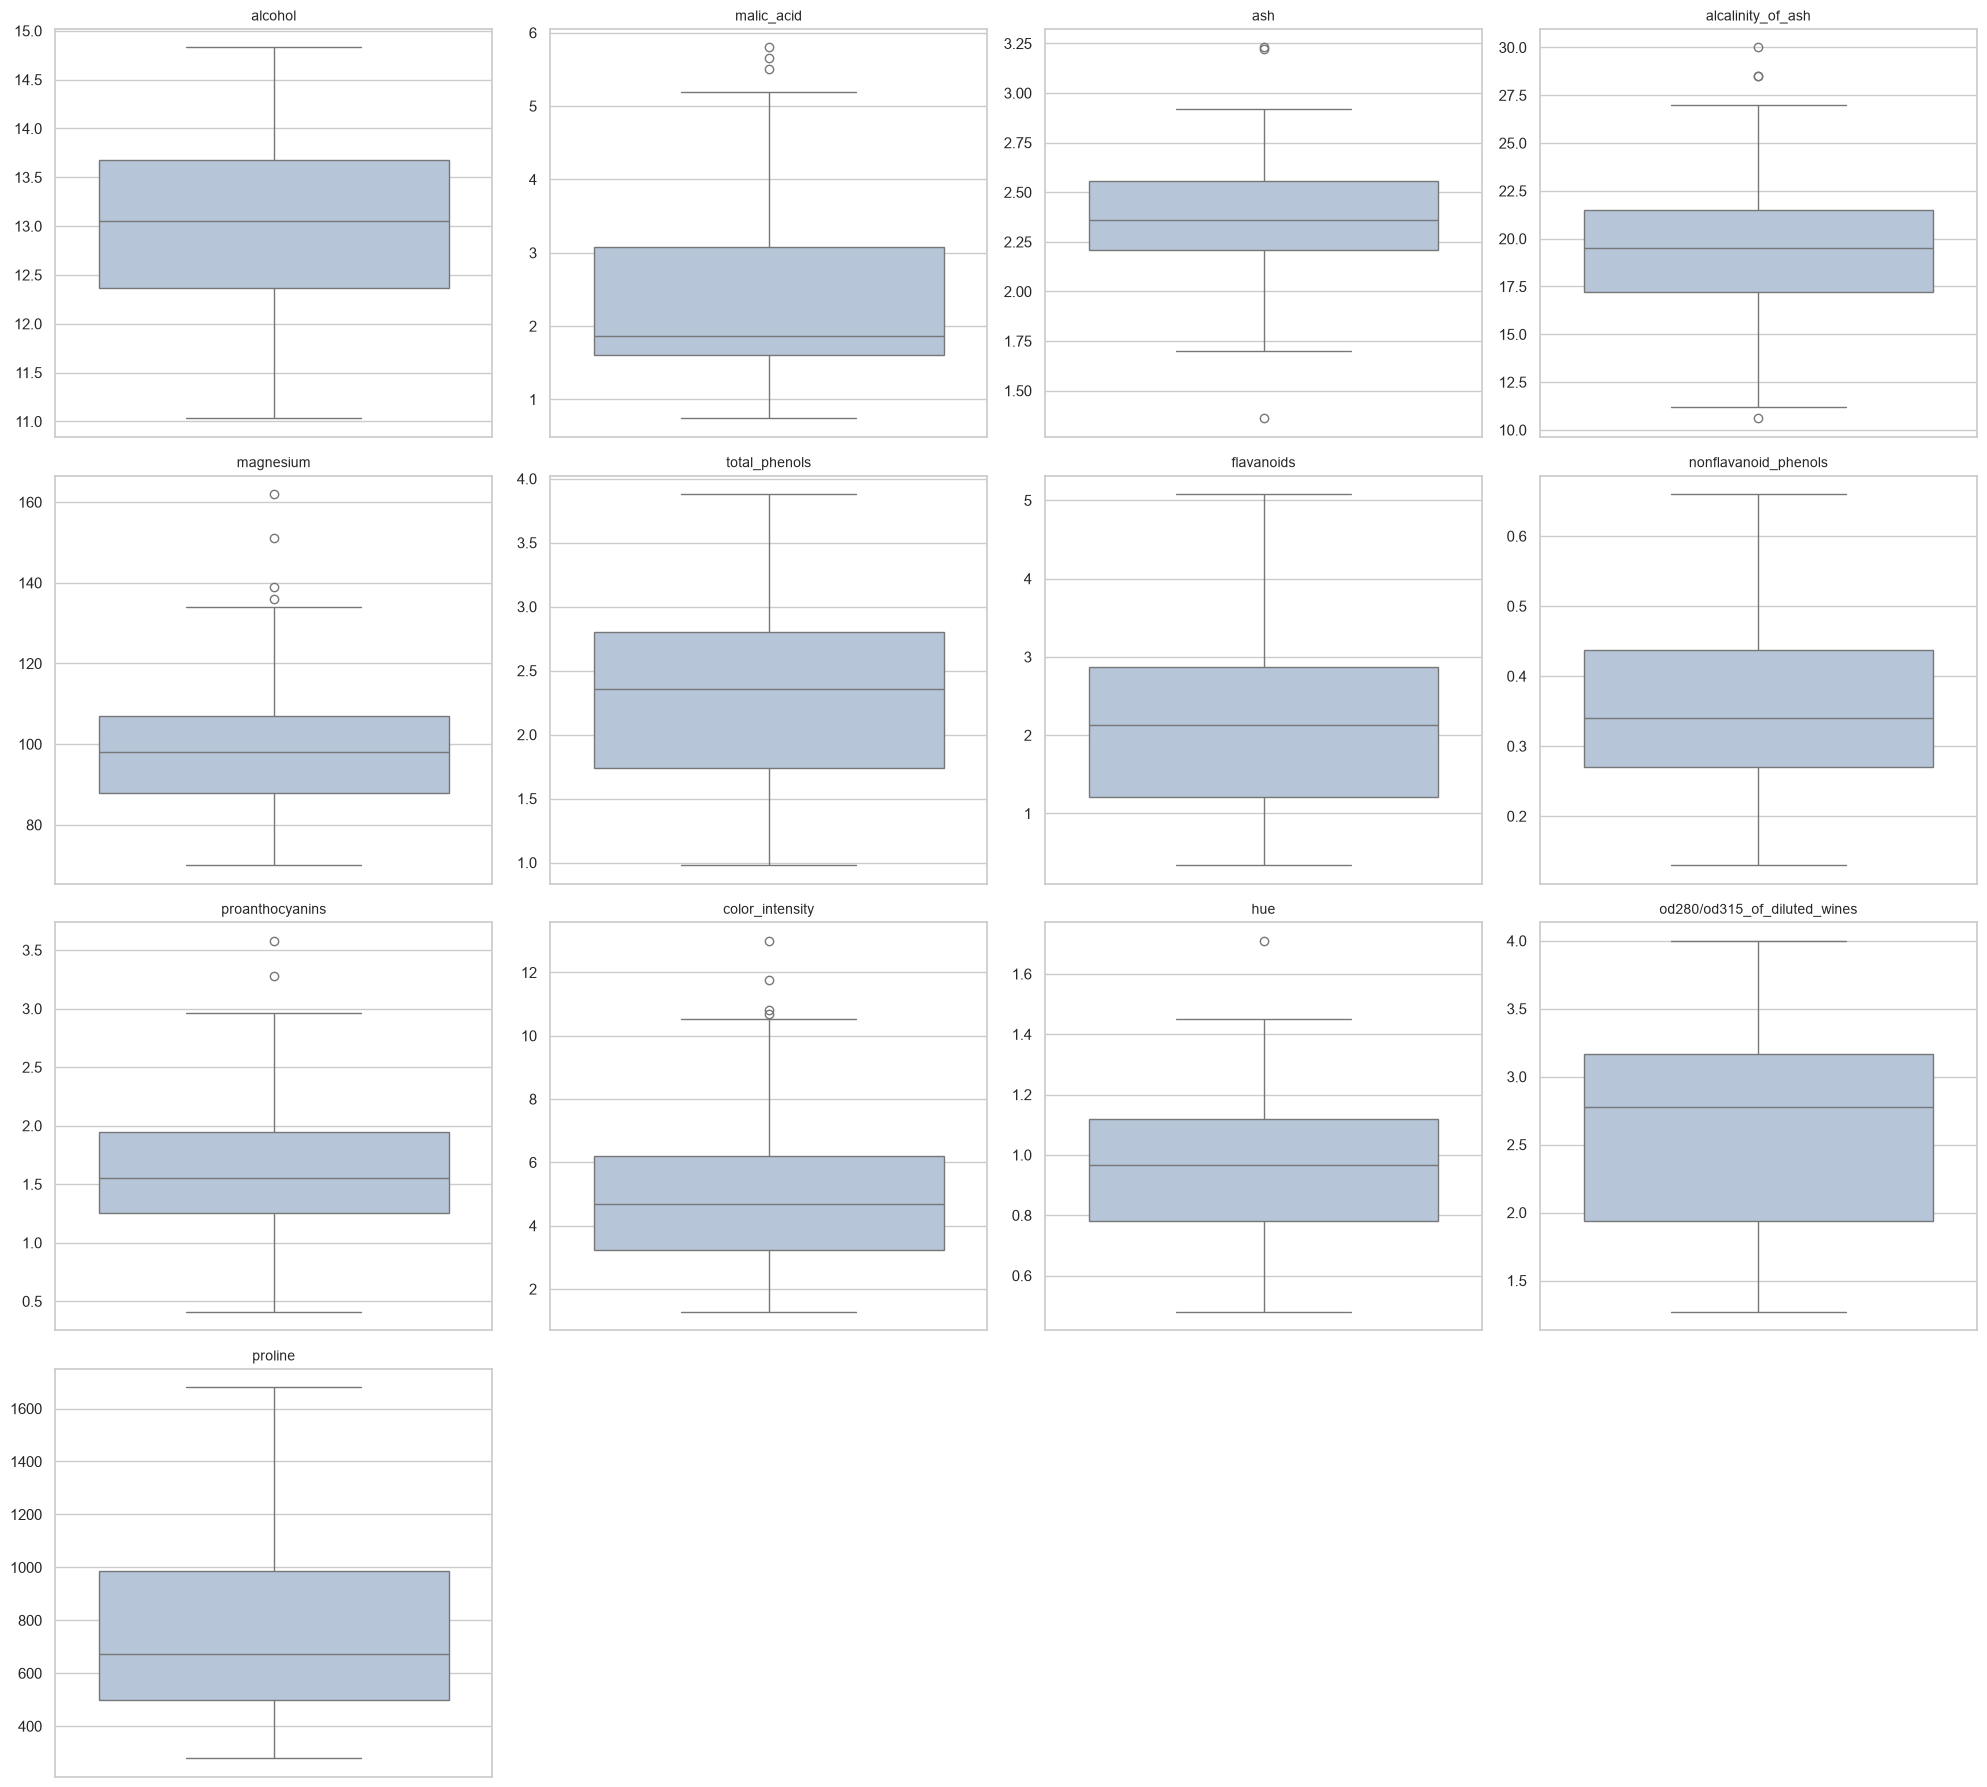

In [10]:
# Посмотрим на выбросы глазами через "ящики с усами".
# Признаков 13 — разложим их в сетку 4 на 4.

# Создаём фигуру: 4 строки, 4 столбца (16 мест, 13 займём).
fig, axes = plt.subplots(4, 4, figsize=(20, 18))

# Превращаем таблицу осей в плоский список.
axes = axes.ravel()

# Рисуем "ящик с усами" для каждого признака.
for i, col in enumerate(X.columns):
    # Прямоугольник — центральная половина данных,
    # точки за усами — выбросы.
    sns.boxplot(y=X[col], ax=axes[i], color="lightsteelblue")

    # Подписываем график.
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("")

# Гасим лишние пустые графики (13 признаков, а мест 16).
for j in range(len(X.columns), len(axes)):
    # axis("off") полностью убирает оси у пустого графика.
    axes[j].axis("off")

plt.tight_layout()
plt.show()

**Что мы увидели:**

* Выбросы есть в **семи** признаках из тринадцати. Больше всего их
  у magnesium, alcalinity_of_ash и color_intensity — по 4 образца (2.25 %).
  Ещё у шести признаков выбросов нет совсем.
* Доля выбросов невелика — не превышает 2.25 % ни в одном признаке.
* Это **не ошибки измерения**. Разные сорта винограда действительно
  сильно различаются по составу, и значения одного сорта могут
  выходить за общие рамки, посчитанные по всем сортам сразу.
* **Мы их не удаляем.** Выбросы здесь несут информацию о сорте.
  Удалив их, мы убрали бы как раз самые характерные образцы.

**Важный вывод:** этот датасет — хороший пример того, что выбросы
не всегда являются мусором, который надо вычистить.
Иногда это самая полезная часть данных.

### 4.5 Распределения признаков

Посмотрим на распределения — как в целом, так и в разрезе сортов.

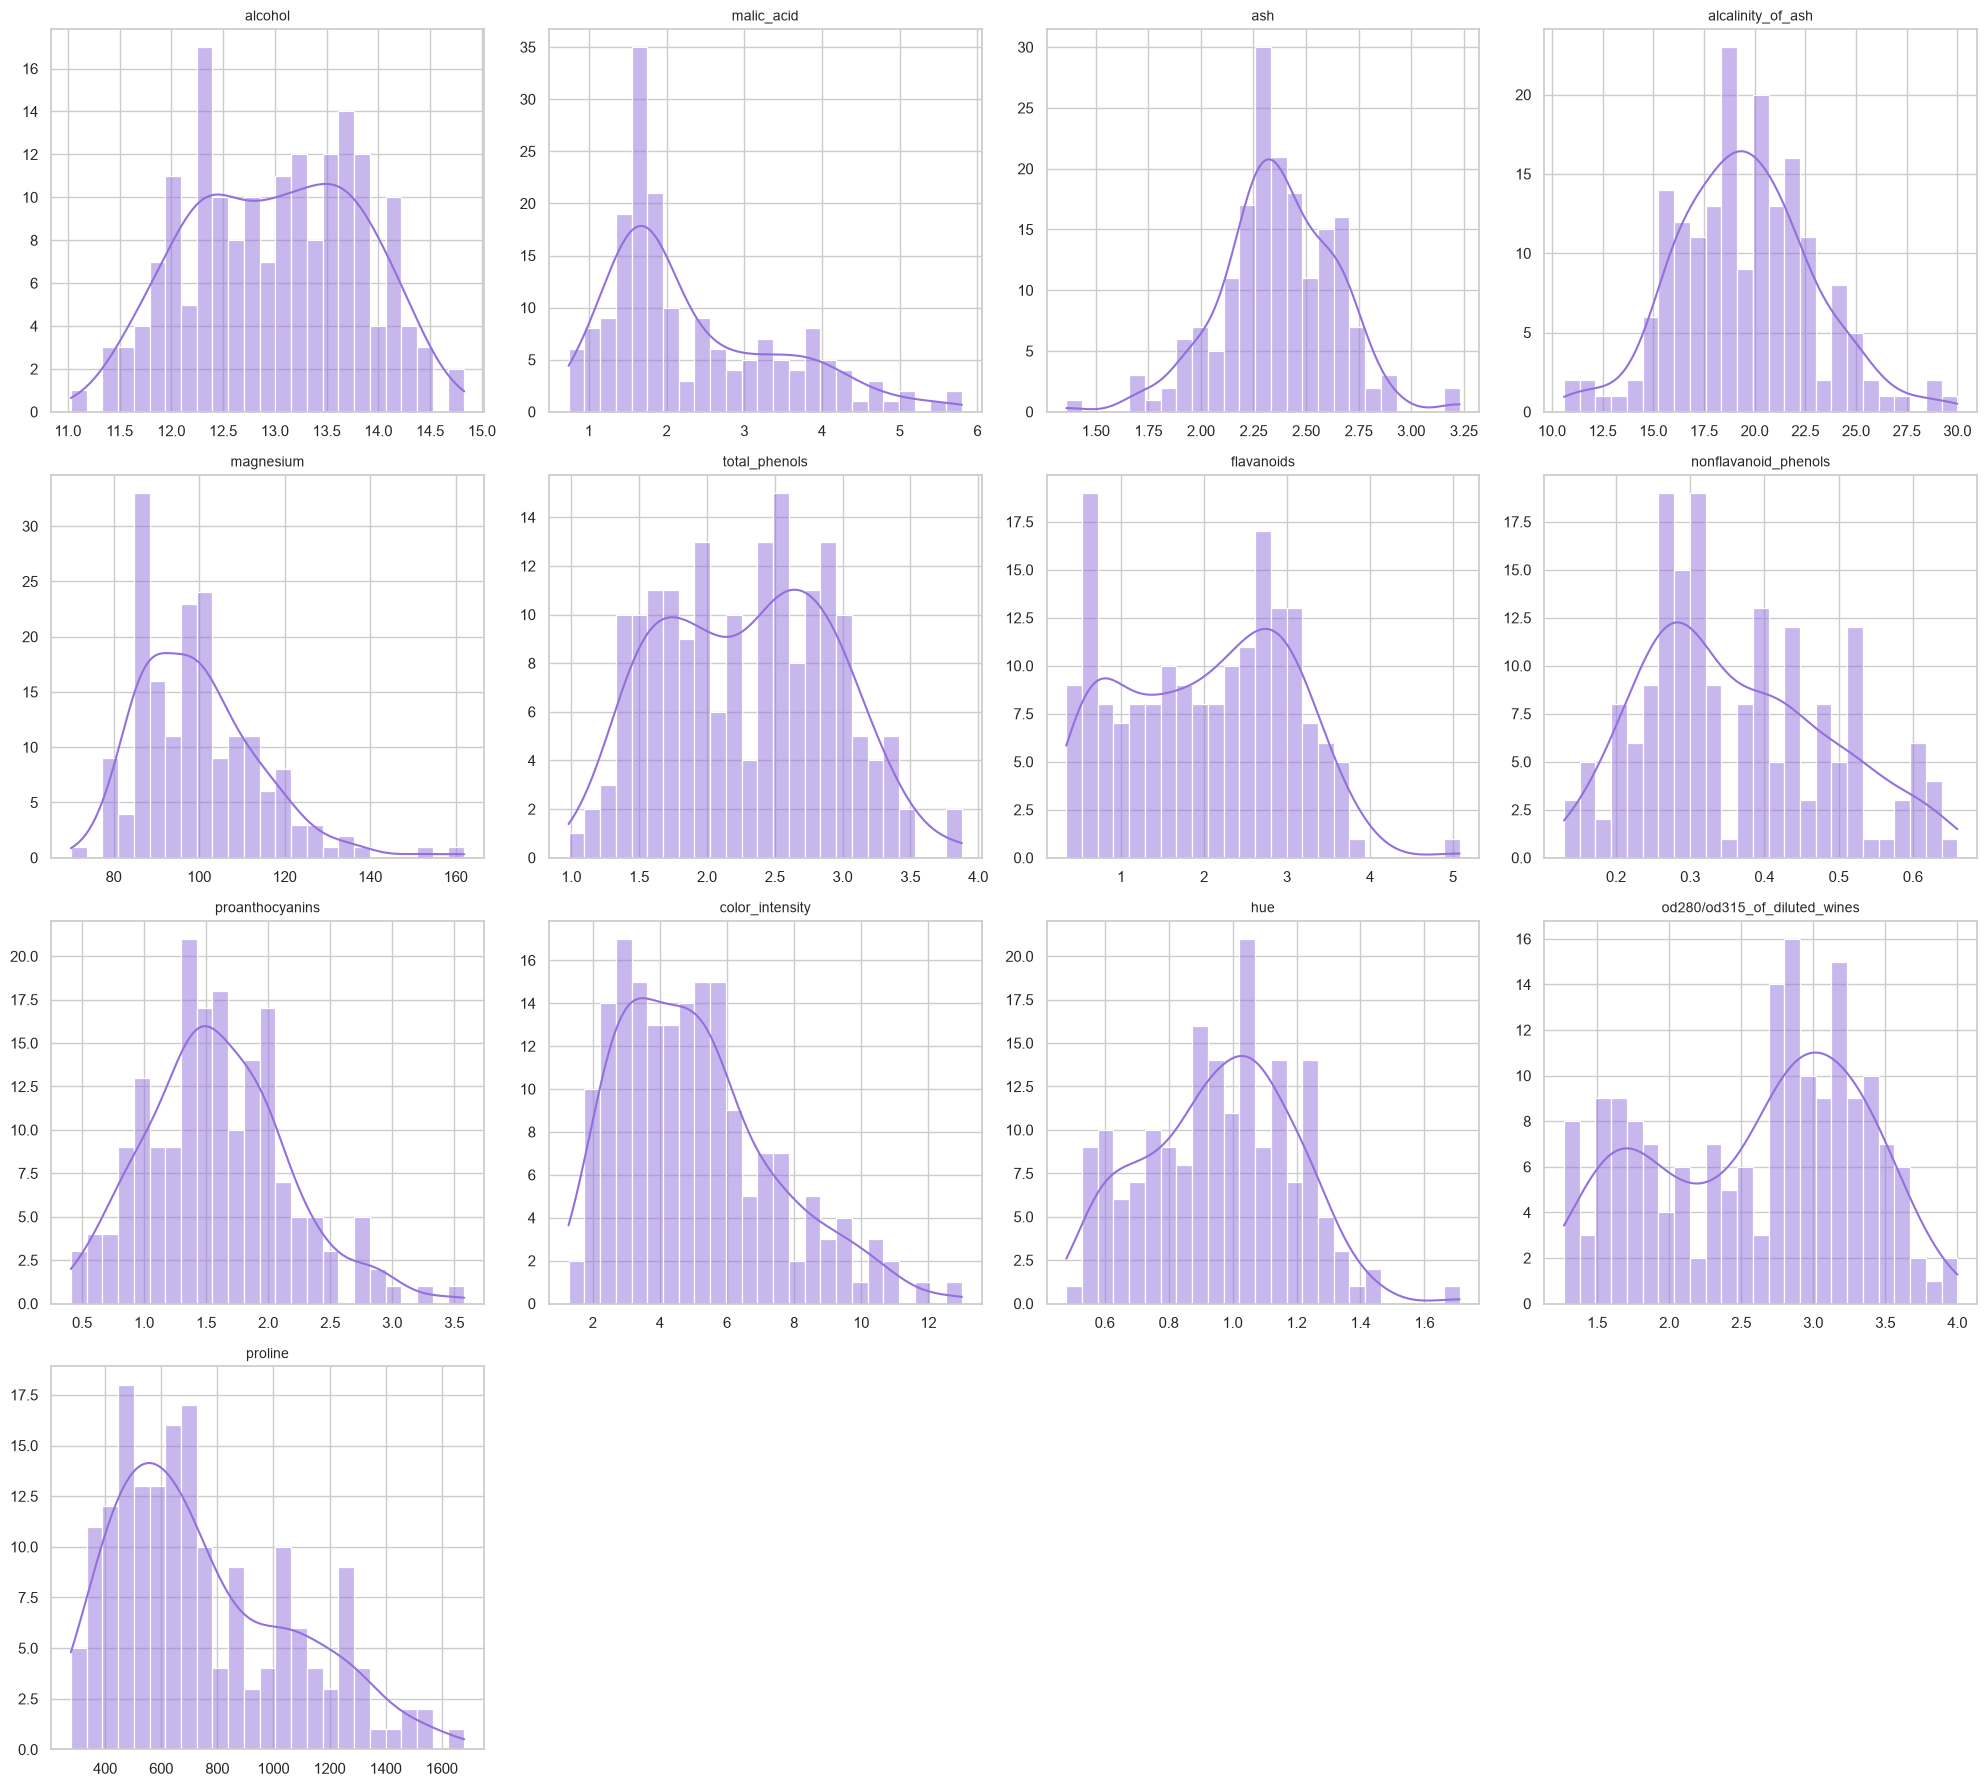

In [11]:
# Строим гистограммы всех 13 признаков в сетке 4 на 4.
fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.ravel()

# Для каждого признака рисуем гистограмму.
for i, col in enumerate(X.columns):
    # bins=25 — на сколько столбиков разбить диапазон.
    # kde=True добавляет плавную линию плотности.
    sns.histplot(X[col], bins=25, kde=True, ax=axes[i], color="mediumpurple")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Гасим пустые графики.
for j in range(len(X.columns), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

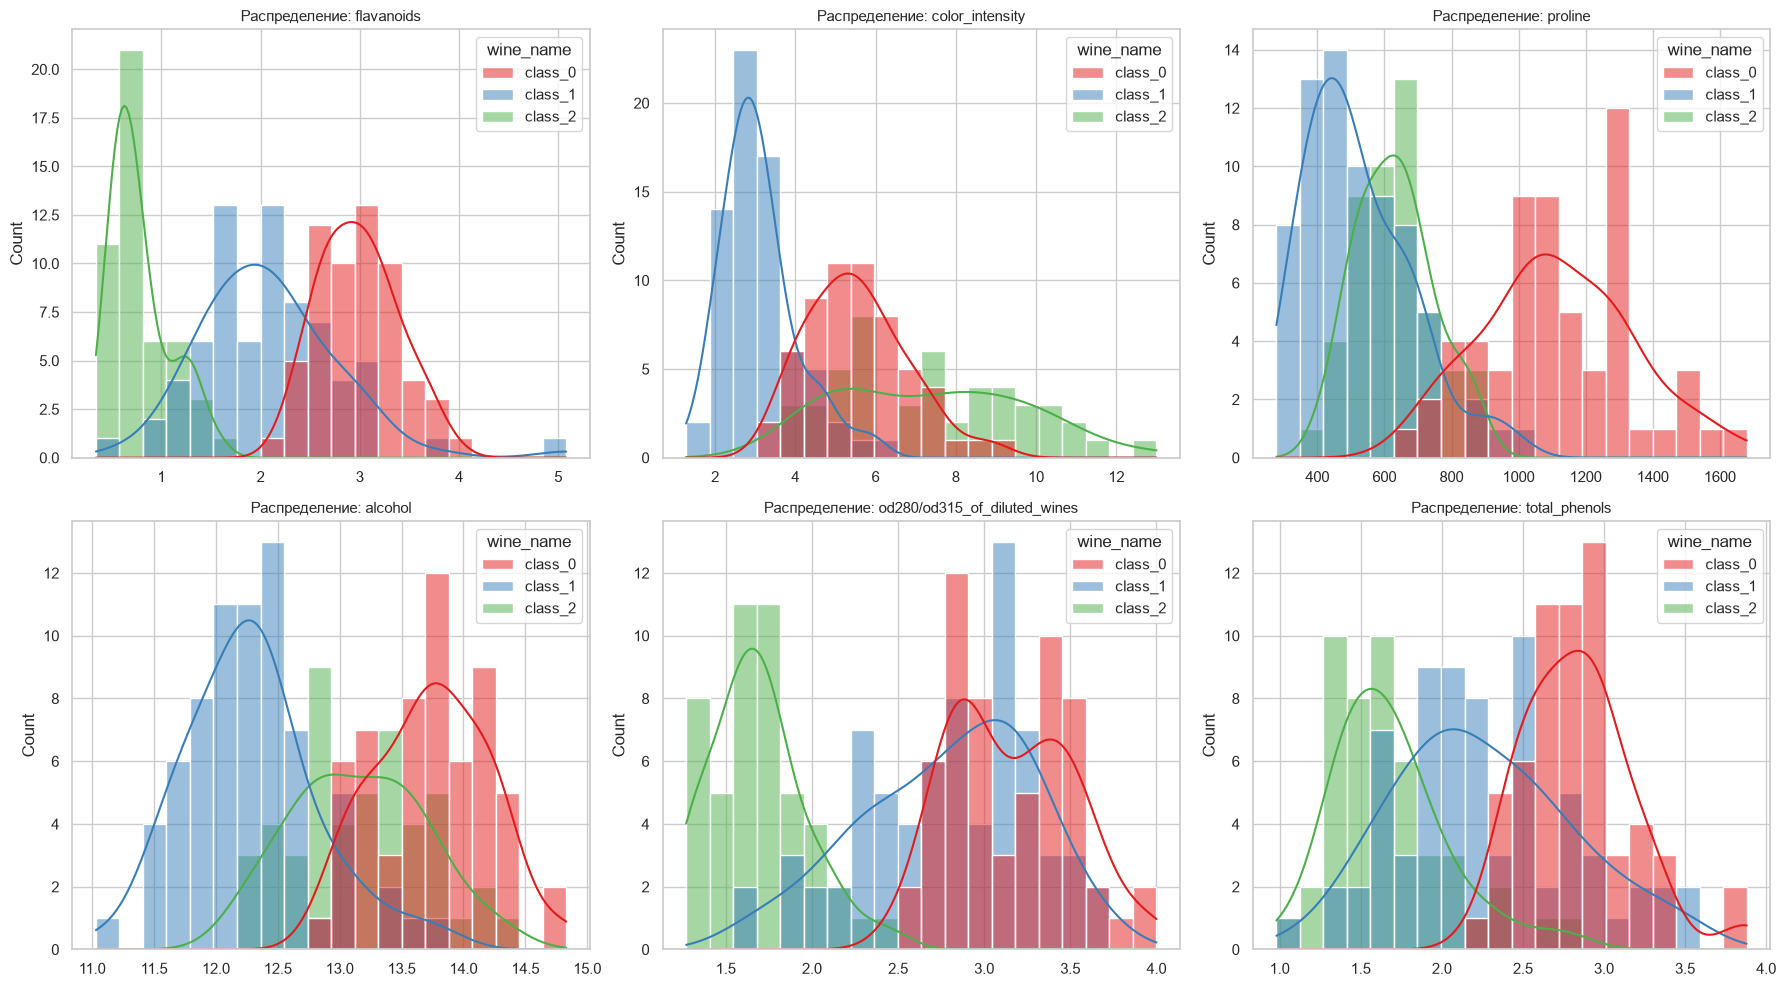

In [12]:
# Теперь самое важное: сравним распределения признаков отдельно
# по сортам. Если распределения разъезжаются — признак полезен.

# Берём 6 признаков, которые обычно лучше всего различают сорта.
compare_cols = [
    "flavanoids",
    "color_intensity",
    "proline",
    "alcohol",
    "od280/od315_of_diluted_wines",
    "total_phenols",
]

# Сетка 2 на 3.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(compare_cols):
    # hue="wine_name" рисует отдельное распределение для каждого сорта.
    # common_norm=False считает плотность каждого сорта независимо,
    # иначе малочисленный сорт выглядел бы ниже просто потому, что его меньше.
    sns.histplot(
        data=df,
        x=col,
        hue="wine_name",
        bins=20,
        kde=True,
        ax=axes[i],
        palette="Set1",
        common_norm=False,
    )

    # Подписываем график и убираем подпись оси X.
    axes[i].set_title(f"Распределение: {col}", fontsize=11)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

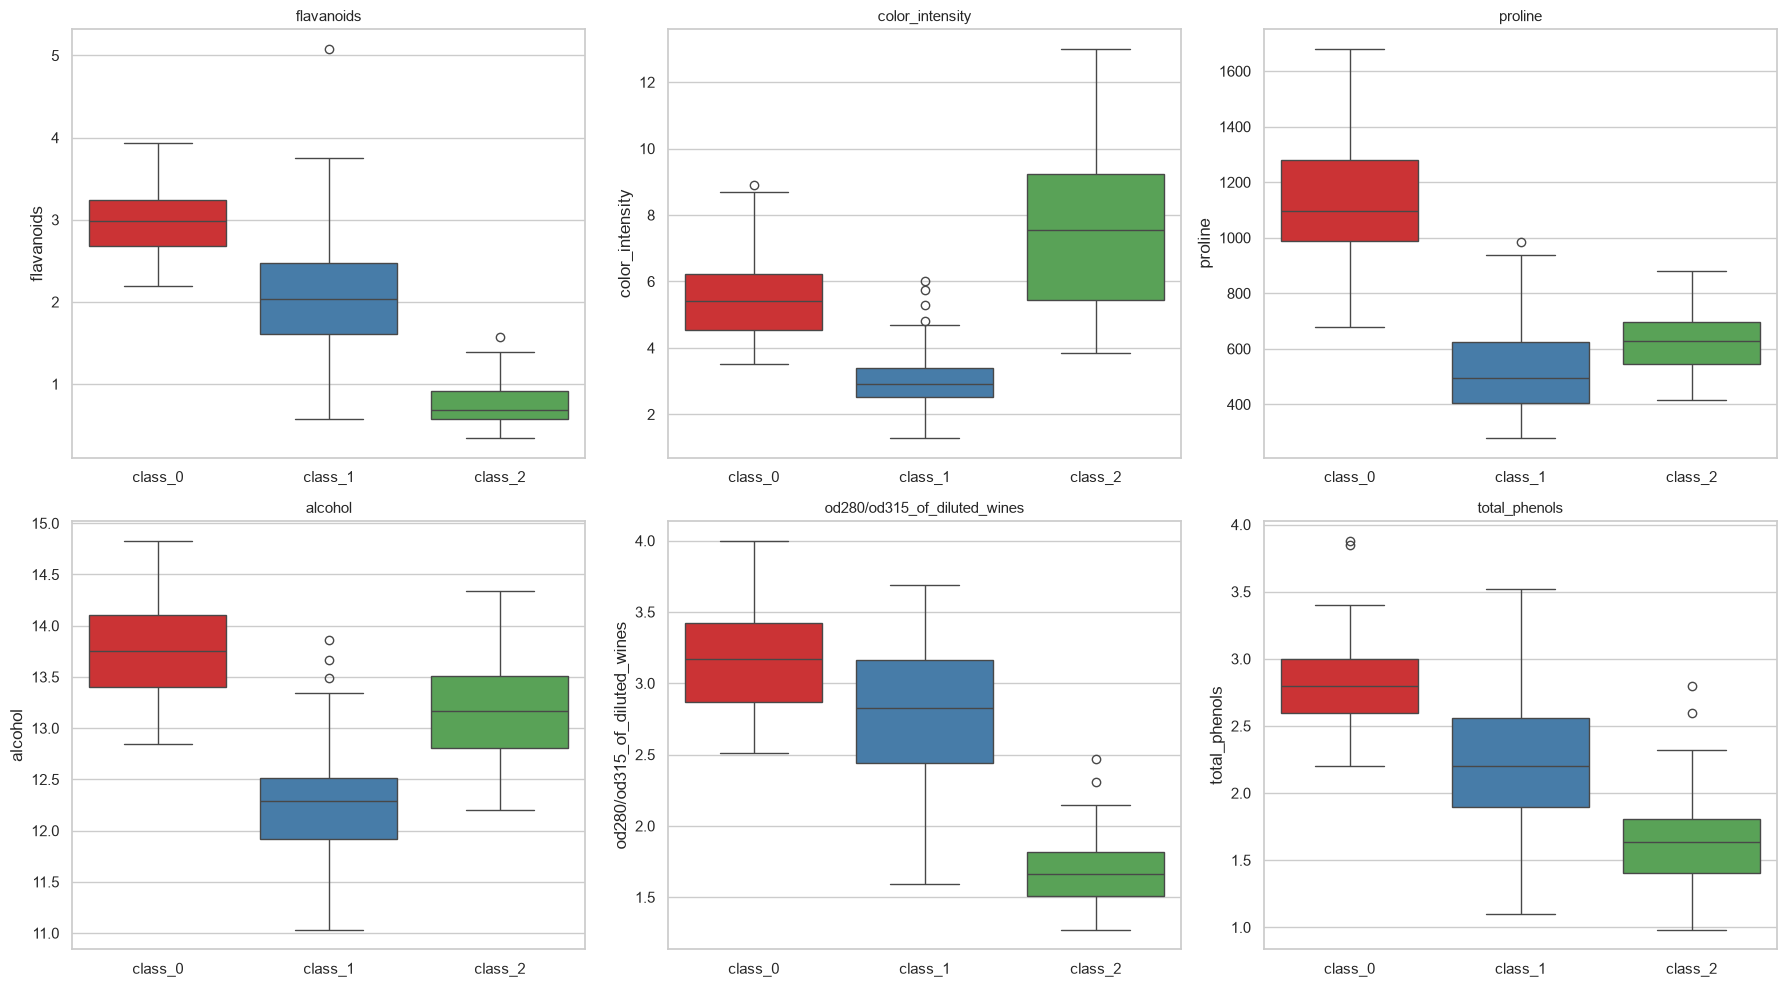

In [13]:
# Ещё один очень наглядный способ сравнить сорта — "ящики с усами"
# по сортам. Так сразу видно, какой признак их разделяет.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(compare_cols):
    # hue="wine_name" — отдельный "ящик" для каждого сорта.
    sns.boxplot(
        data=df,
        x="wine_name",
        y=col,
        hue="wine_name",
        ax=axes[i],
        palette="Set1",
        legend=False,
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

**Что мы увидели:**

* **flavanoids, od280/od315 и total_phenols** — эти три признака
  разделяют сорта наиболее чётко. "Ящики" трёх сортов стоят на разных
  уровнях и почти не пересекаются.
* **proline и hue** разделяют сорта тоже хорошо, хотя у proline
  есть несколько далеко отстоящих точек.
* **alcohol** разделяет сорта частично: class_1 заметно отличается,
  а class_0 и class_2 перекрываются сильнее.
* **color_intensity** на первый взгляд кажется сильным признаком,
  но на самом деле разделяет заметно слабее — убедимся в этом
  в пункте 4.6, где посчитаем корреляции.
* Все признаки имеют правостороннее скошение: большинство значений
  лежат ниже среднего, но есть длинный хвост крупных.

**Практический вывод:** уже до обучения модели видно, что
flavanoids и proline будут главными признаками для определения сорта.
Проверим это позже через важность признаков.

### 4.6 Матрица корреляции

**Корреляция** — число от −1 до +1, показывающее связь двух признаков.

В этом датасете корреляции особенно интересны: часть признаков связана
напрямую, а часть — отрицательно. Это типично для химического состава:
чем больше одних веществ, тем обычно меньше других.

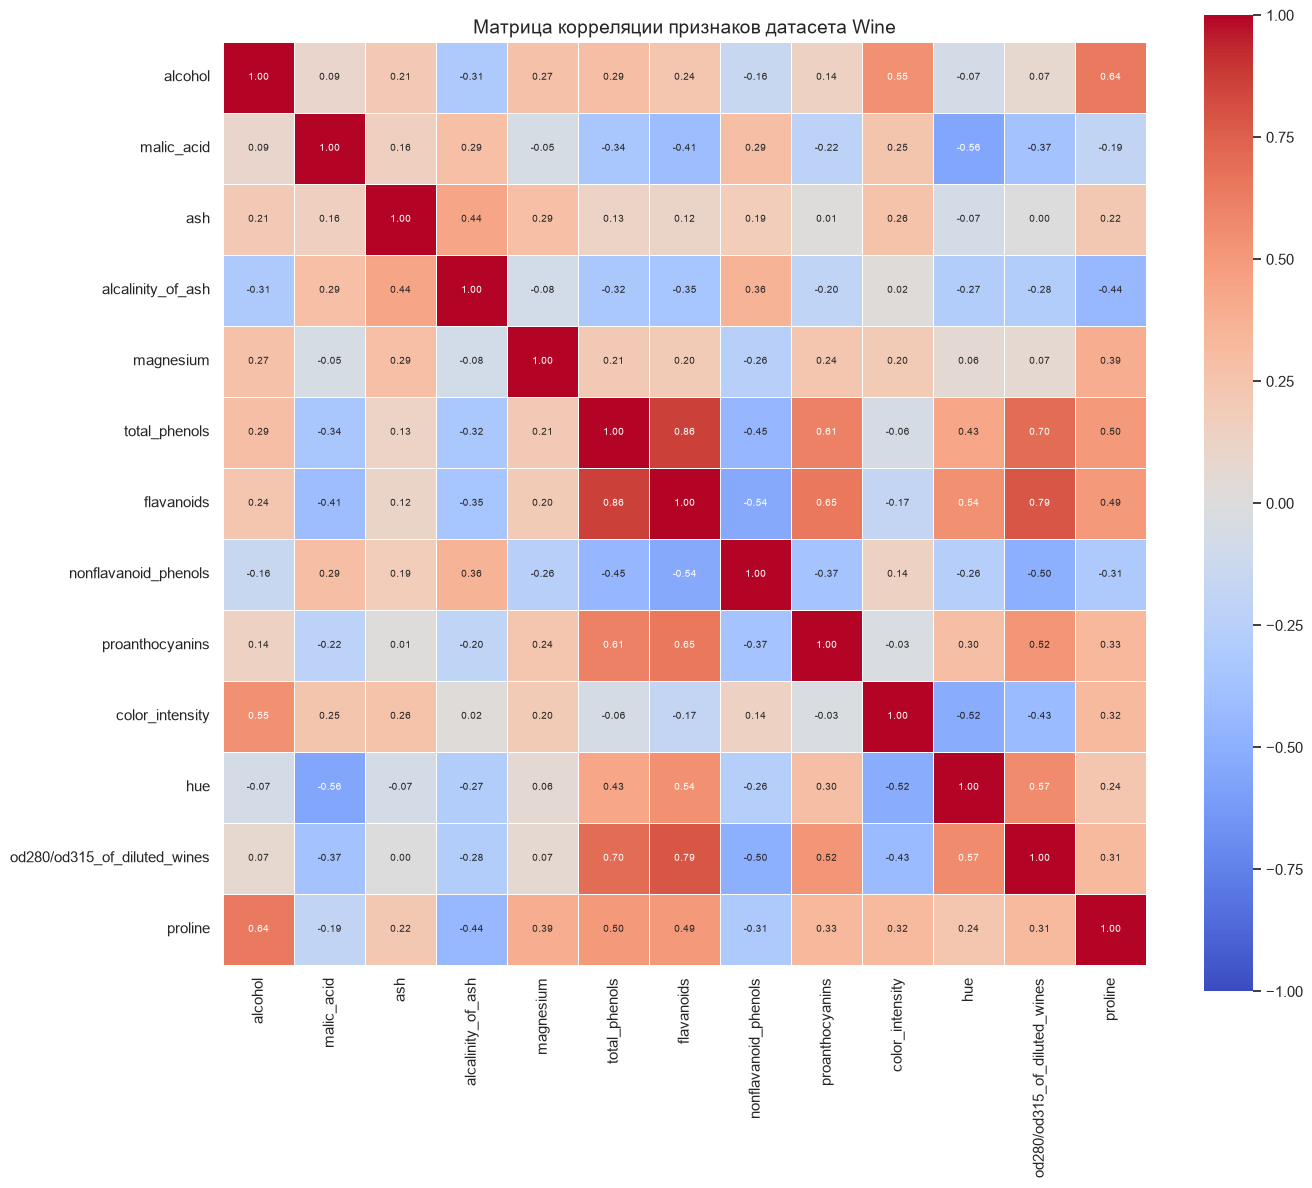

In [14]:
# Считаем корреляцию между всеми парами числовых признаков.
corr_matrix = X.corr()

# Матрица 13 на 13 — рисуем тепловую карту.
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    annot=True,       # подписываем числа в ячейках
    fmt=".2f",        # два знака после запятой
    cmap="coolwarm",  # синий — минус, красный — плюс
    center=0,         # белый = нулевая корреляция
    square=True,      # квадратные ячейки
    linewidths=0.5,   # тонкая рамка между ячейками
    annot_kws={"size": 7},  # мелкий шрифт, иначе числа не влезут
    vmin=-1, vmax=1,  # фиксируем шкалу от -1 до 1
    ax=ax,
)

ax.set_title("Матрица корреляции признаков датасета Wine", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Найдём самые сильные связи между признаками — как положительные,
# так и отрицательные.

# .stack() превращает матрицу в столбец со всеми парами значений.
pairs = corr_matrix.stack()

# Убираем пары признака с самим собой — там всегда ровно 1.0.
pairs = pairs[pairs < 1.0]

# Сортируем по убыванию корреляции и берём 10 самых сильных связей.
top_pairs = pairs.sort_values(ascending=False).head(10).reset_index()
top_pairs.columns = ["Признак 1", "Признак 2", "Корреляция"]
top_pairs["Корреляция"] = top_pairs["Корреляция"].round(4)

print("Самые сильные ПОЛОЖИТЕЛЬНЫЕ связи:")
top_pairs

Самые сильные ПОЛОЖИТЕЛЬНЫЕ связи:


,Признак 1,Признак 2,Корреляция
0,total_phenols,flavanoids,0.8646
1,flavanoids,total_phenols,0.8646
2,od280/od315_of_diluted_wines,flavanoids,0.7872
3,flavanoids,od280/od315_of_diluted_wines,0.7872
4,total_phenols,od280/od315_of_diluted_wines,0.6999
5,od280/od315_of_diluted_wines,total_phenols,0.6999
6,proanthocyanins,flavanoids,0.6527
7,flavanoids,proanthocyanins,0.6527
8,alcohol,proline,0.6437
9,proline,alcohol,0.6437


In [16]:
# Теперь отдельно посмотрим самые сильные ОТРИЦАТЕЛЬНЫЕ связи.
# Отрицательная корреляция означает: чем больше одного вещества,
# тем меньше другого.
worst_pairs = pairs.sort_values(ascending=True).head(10).reset_index()
worst_pairs.columns = ["Признак 1", "Признак 2", "Корреляция"]
worst_pairs["Корреляция"] = worst_pairs["Корреляция"].round(4)

print("Самые сильные ОТРИЦАТЕЛЬНЫЕ связи:")
worst_pairs

Самые сильные ОТРИЦАТЕЛЬНЫЕ связи:


,Признак 1,Признак 2,Корреляция
0,malic_acid,hue,-0.5613
1,hue,malic_acid,-0.5613
2,flavanoids,nonflavanoid_phenols,-0.5379
3,nonflavanoid_phenols,flavanoids,-0.5379
4,color_intensity,hue,-0.5218
5,hue,color_intensity,-0.5218
6,od280/od315_of_diluted_wines,nonflavanoid_phenols,-0.5033
7,nonflavanoid_phenols,od280/od315_of_diluted_wines,-0.5033
8,total_phenols,nonflavanoid_phenols,-0.4499
9,nonflavanoid_phenols,total_phenols,-0.4499


In [17]:
# Считаем корреляцию каждого признака с номером сорта.
# Это подскажет, какие признаки полезны для определения сорта.
corr_with_class = df[X.columns.tolist() + ["wine_class"]].corr()["wine_class"].drop("wine_class")

# Сортируем по абсолютной силе связи — важен и плюс, и минус.
corr_with_class = corr_with_class.sort_values(key=abs, ascending=False)

print("Связь признаков с номером сорта (0, 1, 2):")
print(corr_with_class.round(4).to_string())

Связь признаков с номером сорта (0, 1, 2):
flavanoids                     -0.8475
od280/od315_of_diluted_wines   -0.7882
total_phenols                  -0.7192
proline                        -0.6337
hue                            -0.6174
alcalinity_of_ash               0.5179
proanthocyanins                -0.4991
nonflavanoid_phenols            0.4891
malic_acid                      0.4378
alcohol                        -0.3282
color_intensity                 0.2657
magnesium                      -0.2092
ash                            -0.0496


**Выводы по корреляции:**

* **Самая сильная положительная связь:** flavanoids ↔ total_phenols — около +0.86,
  и flavanoids ↔ od280/od315 — около +0.79. Это химически осмысленно:
  флавоноиды — это и есть часть фенолов, поэтому они связаны по самой природе.
* **Самая сильная отрицательная связь:** malic_acid ↔ hue — около −0.56.
  Следом идёт flavanoids ↔ nonflavanoid_phenols — около −0.54.
  Логика понятна: если флавоноидов много, доля нефлавоноидных
  соединений падает.
* **Признаки с самой сильной связью с сортом:** flavanoids (−0.85),
  od280/od315 (−0.79), total_phenols (−0.72), proline (−0.63), hue (−0.62).
  Отрицательный знак означает: чем больше значение признака,
  тем меньше номер сорта. Например, сорт class_0 содержит
  больше всего флавоноидов.
* **Важное наблюдение:** color_intensity со связью всего +0.27
  и alcohol (−0.33) оказались среди **самых слабых** по корреляции
  с сортом. Запомним это — дальше будет интересное расхождение
  с важностью признаков.
* **Мультиколлинеарность есть, но для леса это не проблема.**
  Случайный лес специально устроен так, что на каждом разбиении
  рассматривает случайное подмножество признаков. Поэтому
  связанные между собой признаки не мешают друг другу —
  в отличие от линейных моделей.

**Оговорка про корреляцию с номером сорта.** Номера 0, 1, 2 — это метки,
между ними нет "расстояния". Корреляция здесь служит лишь ориентиром
для оценки полезности признака, а не точной мерой.

## 5. Что такое случайный лес и зачем он нужен

**Проблема одиночного дерева.** В прошлом ноутбуке мы видели:
дерево без ограничений идеально описывает обучающие данные,
но на новых данных работает хуже. Оно переобучается.

**Идея случайного леса.** Вместо одного дерева построим много деревьев
и усредним их ответы. Каждое дерево обучается на своей случайной
выборке данных и рассматривает случайное подмножество признаков.
За счёт этого деревья получаются разными, а их ошибки — независимыми.
Когда мы усредняем ответы, случайные ошибки взаимно гасятся.

Аналогия: один эксперт может ошибиться, но если спросить сотню
разных экспертов и взять мнение большинства — ошибка маловероятна.

**Как работает голосование.** Каждое дерево "голосует" за один из сортов.
Побеждает сорт, набравший больше голосов. Дополнительно лес может
выдавать вероятность: например, 70 % голосов за class_1.

**Ключевые параметры:**

* **n_estimators** — сколько деревьев в лесу. Больше — стабильнее,
  но дольше обучение. Обычно берут от 100.
* **max_depth** — максимальная глубина каждого дерева.
* **max_features** — сколько признаков рассматривать на каждом разбиении.

### 5.1 Разделение данных

Проверять модель на тех же данных, на которых она училась, нельзя.
Делим данные:

* **70 %** — обучение;
* **30 %** — проверка.

Параметр stratify=y сохранит пропорцию сортов в обеих частях.
Это особенно важно здесь, так как классы в датасете несбалансированы.

In [18]:
# Фиксируем зерно случайности для воспроизводимости.
RANDOM_STATE = 42

# Делим данные на обучающую и тестовую части.
# stratify=y сохраняет пропорцию сортов в обеих частях.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Обучающие признаки X_train:", X_train.shape)
print("Тестовые признаки  X_test :", X_test.shape)
print()

# Проверяем, что пропорции сортов сохранились в обеих частях.
print("Распределение сортов в обучении:")
print(y_train.value_counts().sort_index().to_string())
print()
print("Распределение сортов в тесте:")
print(y_test.value_counts().sort_index().to_string())

Обучающие признаки X_train: (124, 13)
Тестовые признаки  X_test : (54, 13)

Распределение сортов в обучении:
wine_class
0    41
1    50
2    33

Распределение сортов в тесте:
wine_class
0    18
1    21
2    15


### 5.2 Обучение базовой модели

Обучим лес из 100 деревьев — это стандартное значение,
которое хорошо работает "из коробки" в большинстве задач.

In [19]:
# Создаём модель случайного леса.
model = RandomForestClassifier(
    # n_estimators — количество деревьев в лесу.
    # 100 — стандартное значение: достаточно для стабильного результата.
    n_estimators=100,

    # random_state — воспроизводимость результата.
    # Лес использует случайность, поэтому без этого параметра
    # результат менялся бы при каждом запуске.
    random_state=RANDOM_STATE,
)

# Обучаем модель на тренировочных данных.
# Лес строит 100 деревьев, каждое на своей случайной подвыборке.
model.fit(X_train, y_train)

print("Модель случайного леса обучена.")
print()
print("Параметры модели:")
print("  Количество деревьев :", model.n_estimators)
print("  Число признаков     :", model.n_features_in_)
print("  Классы              :", model.classes_)

Модель случайного леса обучена.

Параметры модели:
  Количество деревьев : 100
  Число признаков     : 13
  Классы              : [0 1 2]


### 5.3 Как количество деревьев влияет на качество

Проверим, сколько деревьев действительно нужно. Это важный
практический вопрос: лишние деревья замедляют работу,
не добавляя качества.

Используем **кросс-валидацию** — более надёжный способ оценки,
чем одно разделение на обучение и тест. При кросс-валидации данные
делятся на несколько частей, и модель обучается и проверяется
по очереди на каждой из них.

In [20]:
# Создаём список значений для проверки: от 1 дерева до 200.
n_trees_list = [1, 5, 10, 25, 50, 100, 150, 200]

# Создаём пустой список для результатов.
cv_results = []

# Перебираем каждое значение количества деревьев.
for n in n_trees_list:

    # Создаём лес с заданным числом деревьев.
    rf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)

    # Проводим кросс-валидацию на 5 частях.
    # cross_val_score обучает модель 5 раз, каждый раз проверяя
    # на своей части данных, и возвращает 5 значений точности.
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="accuracy")

    # Сохраняем среднее значение и стандартное отклонение.
    cv_results.append({
        "Деревьев": n,
        "Средняя точность": round(scores.mean(), 4),
        "Отклонение": round(scores.std(), 4),
    })

# Превращаем результаты в таблицу.
cv_df = pd.DataFrame(cv_results)

print("Влияние количества деревьев на качество (кросс-валидация на 5 частях):")
cv_df

Влияние количества деревьев на качество (кросс-валидация на 5 частях):


,Деревьев,Средняя точность,Отклонение
0,1,0.8457,0.0890
1,5,0.9427,0.0718
2,10,0.9513,0.0471
3,25,0.9757,0.0199
4,50,0.9673,0.0310
5,100,0.9673,0.0310
6,150,0.9753,0.0332
7,200,0.9753,0.0332


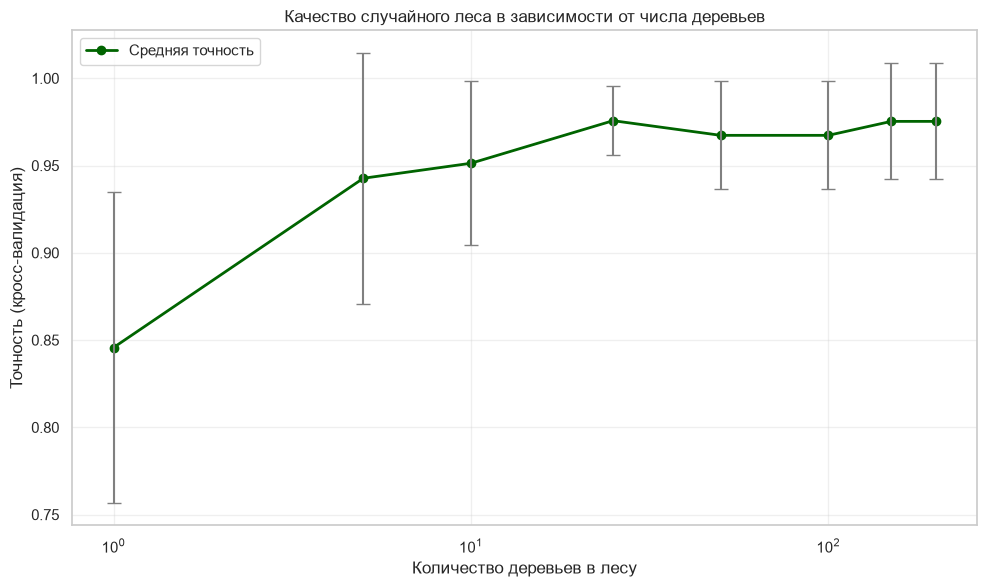

In [21]:
# Нарисуем график зависимости качества от числа деревьев.
fig, ax = plt.subplots(figsize=(10, 6))

# Рисуем линию среднего качества.
ax.plot(cv_df["Деревьев"], cv_df["Средняя точность"],
        marker="o", linewidth=2, color="darkgreen", label="Средняя точность")

# Добавляем "усы" — стандартное отклонение между фолдами.
# yerr показывает разброс результата между частями кросс-валидации.
ax.errorbar(cv_df["Деревьев"], cv_df["Средняя точность"],
            yerr=cv_df["Отклонение"], fmt="none", ecolor="gray", capsize=5)

# Подписываем оси и заголовок.
ax.set_xlabel("Количество деревьев в лесу")
ax.set_ylabel("Точность (кросс-валидация)")
ax.set_title("Качество случайного леса в зависимости от числа деревьев")

# Логарифмическая шкала по X — так видны и малые, и большие значения.
ax.set_xscale("log")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Как читать этот график:**

* При **1 дереве** качество заметно ниже и разброс большой.
  Одно дерево может сильно ошибаться — это ожидаемо.
* Уже при **10–25 деревьях** качество быстро выходит на высокий уровень.
* Начиная примерно с **25–50 деревьев** кривая выходит на плато
  около 0.97 и дальше почти не меняется.
  Дальнейшее увеличение числа деревьев не улучшает результат.
* **Серые "усы"** показывают разброс между частями кросс-валидации.
  Они заметно короче при большом числе деревьев: чем больше деревьев,
  тем **стабильнее** результат.

**Практический вывод:** 100 деревьев — разумный выбор.
Это уже далеко за точкой насыщения, а обучение всё ещё быстрое.
Увеличивать до 1000 смысла нет: качество не изменится,
а время работы вырастет.

**Важное замечание про кросс-валидацию.** Отклонение никогда не равно нулю,
даже если среднее качество очень высокое. Это нормально:
на разных частях данных модель показывает слегка разные результаты.
Именно поэтому кросс-валидация честнее одного разделения —
она показывает не одну цифру, а диапазон.

## 6. Оценка качества модели

Обучим финальную модель на 100 деревьях и подробно разберём её качество.

В этой задаче классов три, и они несбалансированы, поэтому
смотреть нужно не только на accuracy, но и на метрики по каждому сорту.

In [22]:
# Делаем прогноз для тестовой выборки.
# Эти образцы модель не видела при обучении.
y_pred = model.predict(X_test)

# Считаем долю правильных ответов.
accuracy = accuracy_score(y_test, y_pred)

# Считаем точность на обучающей выборке — для сравнения.
train_accuracy = model.score(X_train, y_train)

print("=" * 55)
print("КАЧЕСТВО МОДЕЛИ")
print("=" * 55)
print(f"Accuracy на обучающей выборке : {train_accuracy:.4f}")
print(f"Accuracy на тестовой выборке  : {accuracy:.4f}")
print(f"Разрыв (переобучение)         : {train_accuracy - accuracy:.4f}")
print()

# Полный отчёт по каждому сорту.
report = classification_report(
    y_test,
    y_pred,
    target_names=list(wine.target_names),
    digits=4,
)
print("Подробный отчёт по сортам:")
print(report)

КАЧЕСТВО МОДЕЛИ
Accuracy на обучающей выборке : 1.0000
Accuracy на тестовой выборке  : 1.0000
Разрыв (переобучение)         : 0.0000

Подробный отчёт по сортам:
              precision    recall  f1-score   support

     class_0     1.0000    1.0000    1.0000        18
     class_1     1.0000    1.0000    1.0000        21
     class_2     1.0000    1.0000    1.0000        15

    accuracy                         1.0000        54
   macro avg     1.0000    1.0000    1.0000        54
weighted avg     1.0000    1.0000    1.0000        54



Обратите внимание на разрыв между обучением и тестом.

Случайный лес показывает на обучении результат очень близкий к идеальному,
но на тесте — чуть ниже. Небольшой разрыв нормален: лес всегда
немного переобучается, потому что деревья строятся по обучающим данным.

Главное преимущество перед одиночным деревом в том, что **разрыв
гораздо меньше**. Лес усредняет ответы ста деревьев,
и случайные ошибки отдельных деревьев взаимно гасятся.

### 6.1 Матрица ошибок

Матрица ошибок для трёх сортов — таблица 3 на 3.
По диагонали правильные ответы, вне диагонали — ошибки.

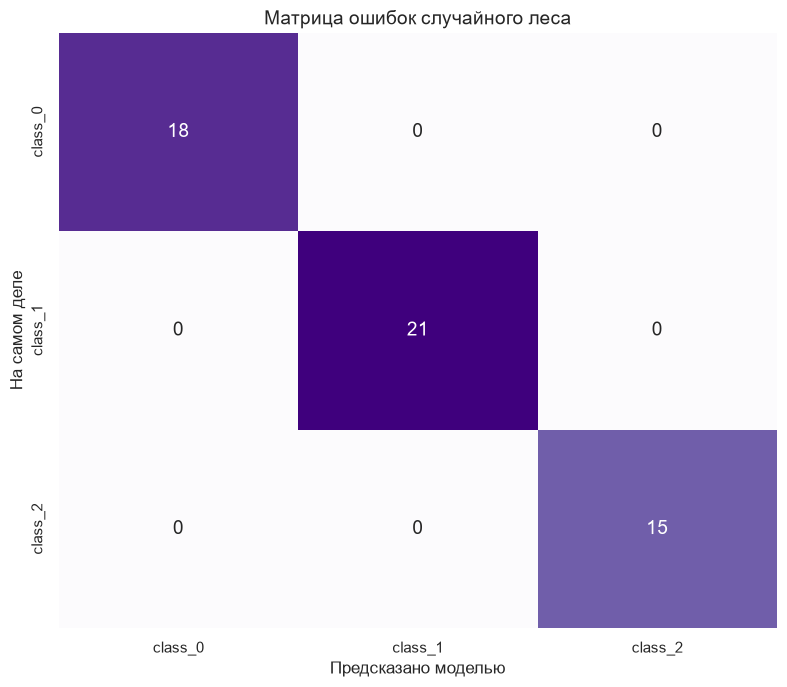

In [23]:
# Считаем матрицу ошибок.
# Строки — истинные сорта, столбцы — предсказанные моделью.
cm = confusion_matrix(y_test, y_pred)

# Рисуем матрицу ошибок в виде тепловой карты.
fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,       # подписываем числа в ячейках
    fmt="d",          # целые числа
    cmap="Purples",   # фиолетовая схема
    cbar=False,       # цветовая шкала здесь не нужна
    xticklabels=list(wine.target_names),  # столбцы — предсказано
    yticklabels=list(wine.target_names),  # строки — на самом деле
    annot_kws={"size": 14},
    ax=ax,
)

ax.set_xlabel("Предсказано моделью", fontsize=12)
ax.set_ylabel("На самом деле", fontsize=12)
ax.set_title("Матрица ошибок случайного леса", fontsize=14)

plt.tight_layout()
plt.show()

In [24]:
# Разберём ошибки модели по каждому сорту.

# Сумма элементов на главной диагонали — число верных ответов.
correct = np.trace(cm)

# Общее число образцов в тестовой выборке.
total = cm.sum()

print(f"Верных ответов: {correct} из {total}")
print()

# Идём по всем ячейкам вне диагонали — там лежат ошибки.
# np.ndenumerate перебирает элементы матрицы вместе с координатами.
print("Разбор ошибок модели:")
found_errors = False

for (i, j), count in np.ndenumerate(cm):
    # Пропускаем диагональ — там правильные ответы.
    if i == j:
        continue

    # Если в ячейке есть значения — это ошибка модели.
    if count > 0:
        found_errors = True
        true_name = wine.target_names[i]
        pred_name = wine.target_names[j]
        print(f"  {count} раз(а): на самом деле {true_name}, "
              f"а модель сказала {pred_name}")

# Если ошибок нет, сообщаем об этом отдельно.
if not found_errors:
    print("  Ошибок нет: модель верно определила все образцы в тестовой выборке.")

Верных ответов: 54 из 54

Разбор ошибок модели:
  Ошибок нет: модель верно определила все образцы в тестовой выборке.


### 6.2 Важность признаков

Одно из главных достоинств случайного леса — он умеет показывать,
какие признаки оказались важными для решения.

**Как считается важность.** Для каждого признака лес смотрит, насколько
он уменьшал "загрязнённость" узлов при разбиении. Чем чаще признак
использовался и чем чище становились узлы после разбиения,
тем выше его важность. Сумма всех важностей равна 1.0.

In [25]:
# .feature_importances_ — массив важностей, по одному числу на признак.
importances = model.feature_importances_

# Собираем таблицу: имя признака и его важность.
importance_df = pd.DataFrame({
    "Признак": wine.feature_names,
    "Важность": importances,
})

# Считаем важность в процентах.
importance_df["Важность, %"] = (importance_df["Важность"] * 100).round(2)

# Сортируем по убыванию важности.
importance_df = importance_df.sort_values("Важность", ascending=False)

print("Важность признаков для определения сорта вина:")
importance_df.reset_index(drop=True)

Важность признаков для определения сорта вина:


,Признак,Важность,"Важность, %"
0,alcohol,0.162715,16.27
1,color_intensity,0.159719,15.97
2,flavanoids,0.156283,15.63
3,proline,0.124081,12.41
4,hue,0.111019,11.10
5,od280/od315_of_diluted_wines,0.098852,9.89
6,total_phenols,0.042004,4.20
7,magnesium,0.034591,3.46
8,malic_acid,0.033700,3.37
9,alcalinity_of_ash,0.028841,2.88


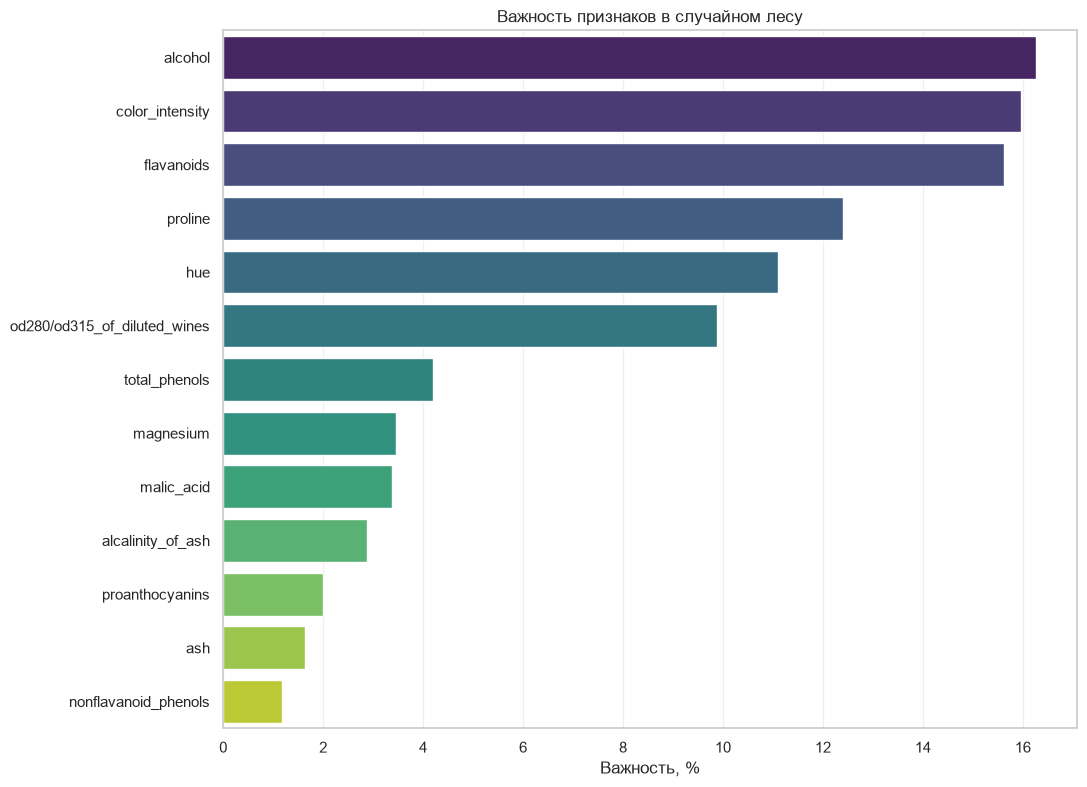

In [26]:
# Нарисуем важность признаков горизонтальными столбиками.
fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=importance_df,
    x="Важность, %",
    y="Признак",
    hue="Признак",
    palette="viridis",
    legend=False,
    ax=ax,
)

ax.set_title("Важность признаков в случайном лесу")
ax.set_xlabel("Важность, %")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Посчитаем, сколько признаков дают вместе 90 % важности.
# Это полезно знать: возможно, часть признаков вообще не нужна.

# Сортируем важности по убыванию.
sorted_imp = importance_df["Важность"].sort_values(ascending=False).values

# Считаем накопленную сумму: cumsum прибавляет значения по очереди.
cumulative = np.cumsum(sorted_imp)

# Находим, после какого по счёту признака накопленная сумма превысила 0.90.
# argmax вернёт номер первого такого элемента, прибавляем 1 для счёта с единицы.
n_for_90 = int(np.argmax(cumulative >= 0.90)) + 1

print(f"Всего признаков: {len(sorted_imp)}")
print(f"Признаков, дающих вместе 90 % важности: {n_for_90}")
print()

# Печатаем эти признаки с их накопленной важностью.
print("Накопленная важность по признакам:")
for k in range(n_for_90):
    name = importance_df["Признак"].values[k]
    print(f"  {k + 1:2d}. {name:35s} важность {sorted_imp[k] * 100:6.2f} %  "
          f"| накопленно {cumulative[k] * 100:6.2f} %")

Всего признаков: 13
Признаков, дающих вместе 90 % важности: 9

Накопленная важность по признакам:
   1. alcohol                             важность  16.27 %  | накопленно  16.27 %
   2. color_intensity                     важность  15.97 %  | накопленно  32.24 %
   3. flavanoids                          важность  15.63 %  | накопленно  47.87 %
   4. proline                             важность  12.41 %  | накопленно  60.28 %
   5. hue                                 важность  11.10 %  | накопленно  71.38 %
   6. od280/od315_of_diluted_wines        важность   9.89 %  | накопленно  81.27 %
   7. total_phenols                       важность   4.20 %  | накопленно  85.47 %
   8. magnesium                           важность   3.46 %  | накопленно  88.93 %
   9. malic_acid                          важность   3.37 %  | накопленно  92.30 %


**Что показала важность признаков:**

* **Лидеры по важности:** alcohol (16.3 %), color_intensity (16.0 %),
  flavanoids (15.6 %) и proline (12.4 %). Дальше идут hue (11.1 %)
  и od280/od315 (9.9 %).
* **Остальные семь признаков** дают вместе лишь около 19 %.
  Всего **9 признаков из 13** набирают 90 % важности.

**Это очень интересное расхождение — разберём его внимательно.**
В пункте 4.6 корреляция с сортом показала, что alcohol (−0.33)
и color_intensity (+0.27) — одни из **самых слабых** признаков.
А важность говорит, что они **главные**. Почему так?

Потому что это **разные вещи**:

* **Корреляция** измеряет линейную связь признака с номером сорта.
  Слабую линейную связь легко пропустить.
* **Важность в дереве** измеряет, насколько признак помогает
  **разделить** классы — а разделение может быть нелинейным.
  Например, сорта могут различаться по alcohol не "чем больше, тем лучше",
  а "средние значения против крайних".

Именно поэтому случайный лес находит пользу там, где линейная
корреляция её не видит. Для линейных моделей (как логистическая
регрессия) слабая корреляция означала бы слабую пользу,
а для леса — нет.

**Важное отличие от дерева решений.** В прошлом ноутбуке дерево
использовало всего 2 признака из 4, а остальные получили ровно 0 %.
Здесь картина иная: из-за случайного выбора признаков на каждом разбиении
лес использует почти все признаки, поэтому важность распределена
более плавно. Это и есть источник устойчивости леса.

**Практический вывод:** можно смело сократить набор до 6 главных
признаков (alcohol, color_intensity, flavanoids, proline, hue, od280/od315) —
вместе они дают более 81 % важности. Качество при этом почти не упадёт,
а модель станет проще и быстрее.

**Важная оговорка.** Важность признаков в лесу нельзя понимать как
"направление влияния". Она показывает только **силу участия** признака
в решениях, но не говорит, больше или меньше значения ведут к тому
или иному сорту. Для направления нужно смотреть на корреляции
(пункт 4.6) или строить дополнительные графики зависимости.

### 6.3 Вероятности предсказаний

Случайный лес умеет выдавать не только ответ, но и **уверенность**
в нём. Это очень полезно на практике: если модель сомневается,
решение можно передать человеку на проверку.

In [28]:
# predict_proba возвращает вероятности всех трёх сортов для каждого образца.
y_proba = model.predict_proba(X_test)

print("Размер массива вероятностей:", y_proba.shape)
print("(строк = образцов в тесте, столбцов = сортов)")
print()

# Показываем вероятности для первых пяти образцов.
proba_df = pd.DataFrame(
    y_proba[:5],
    columns=[f"P({name})" for name in wine.target_names],
)

# Добавляем столбец с предсказанным сортом.
proba_df["Предсказано"] = [wine.target_names[i] for i in y_pred[:5]]

# Добавляем столбец с реальным сортом.
proba_df["На самом деле"] = [wine.target_names[i] for i in y_test.values[:5]]

# Округляем вероятности для читаемости.
for col in [c for c in proba_df.columns if c.startswith("P(")]:
    proba_df[col] = proba_df[col].round(4)

print("Вероятности для первых 5 образцов тестовой выборки:")
proba_df

Размер массива вероятностей: (54, 3)
(строк = образцов в тесте, столбцов = сортов)

Вероятности для первых 5 образцов тестовой выборки:


,P(class_0),P(class_1),P(class_2),Предсказано,На самом деле
0,0.95,0.03,0.02,class_0,class_0
1,0.01,0.97,0.02,class_1,class_1
2,1.00,0.00,0.00,class_0,class_0
3,0.98,0.02,0.00,class_0,class_0
4,0.81,0.19,0.00,class_0,class_0


In [29]:
# Проверим, насколько уверена модель в своих ответах.
# Для каждого образца берём максимальную вероятность — уверенность модели.

# .max(axis=1) берёт максимум по столбцам, то есть по сортам.
confidence = y_proba.max(axis=1)

print("Уверенность модели (максимальная вероятность):")
print(f"  Средняя уверенность  : {confidence.mean():.4f}")
print(f"  Минимальная          : {confidence.min():.4f}")
print(f"  Максимальная         : {confidence.max():.4f}")
print()

# Считаем, сколько образцов модель предсказала уверенно (больше 0.9).
n_confident = (confidence > 0.9).sum()
n_total = len(confidence)
print(f"Образцов с уверенностью выше 0.9: {n_confident} из {n_total} "
      f"({n_confident / n_total * 100:.1f} %)")
print()

# Находим самый неуверенный прогноз — там модель сомневалась сильнее всего.
min_idx = confidence.argmin()
print("Самый неуверенный прогноз:")
print(f"  Вероятности: {np.round(y_proba[min_idx], 4)}")
print(f"  Модель сказала: {wine.target_names[y_pred[min_idx]]}")
print(f"  На самом деле : {wine.target_names[y_test.values[min_idx]]}")
print()
print("Если модель сомневается между двумя сортами, а ответ верный —")
print("это говорит о том, что сорта действительно близки по составу.")

Уверенность модели (максимальная вероятность):
  Средняя уверенность  : 0.8896
  Минимальная          : 0.5500
  Максимальная         : 1.0000

Образцов с уверенностью выше 0.9: 35 из 54 (64.8 %)

Самый неуверенный прогноз:
  Вероятности: [0.23 0.55 0.22]
  Модель сказала: class_1
  На самом деле : class_1

Если модель сомневается между двумя сортами, а ответ верный —
это говорит о том, что сорта действительно близки по составу.


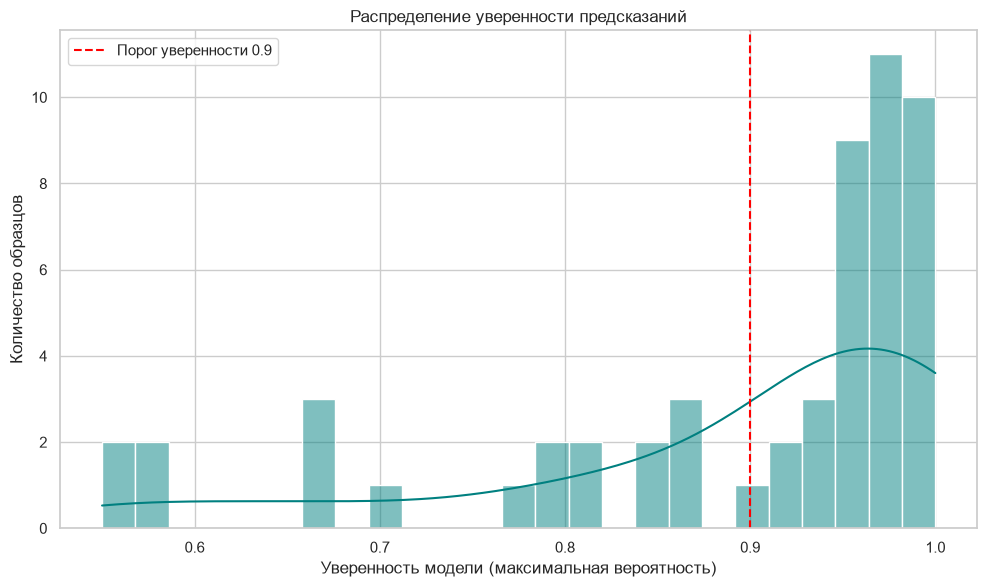

In [30]:
# Нарисуем распределение уверенности модели.
fig, ax = plt.subplots(figsize=(10, 6))

# Строим гистограмму уверенности.
sns.histplot(confidence, bins=25, kde=True, ax=ax, color="teal")

# Добавляем вертикальную линию на уровне 0.9 — порог уверенности.
ax.axvline(0.9, color="red", linestyle="--", label="Порог уверенности 0.9")

ax.set_xlabel("Уверенность модели (максимальная вероятность)")
ax.set_ylabel("Количество образцов")
ax.set_title("Распределение уверенности предсказаний")
ax.legend()

plt.tight_layout()
plt.show()

**Что показывает график:**

* Модель уверена в большинстве ответов: около 65 % предсказаний
  имеют уверенность выше 0.9, а средняя уверенность — 0.89.
* Но примерно треть образцов имеет уверенность ниже 0.9 —
  именно они находятся на границе между сортами.
* Самый неуверенный прогноз дал вероятности 0.23 / 0.55 / 0.22:
  модель колебалась между двумя сортами, но ответ оказался верным.
  Это хороший пример того, что сорта действительно близки по составу.
* Такие "сомнительные" образцы особенно ценны: если это реальное
  производство, их стоило бы отправить на дополнительный химический анализ.

**Практический приём.** Можно ввести правило: если уверенность модели
ниже, скажем, 0.7 — не принимать автоматическое решение, а передавать
случай человеку. Это стандартный подход в промышленных системах.

## 7. Сравнение вариантов случайного леса

Сравним несколько вариантов леса с разными настройками
и выясним, какой из них лучше.

Проверим четыре варианта:

1. **Базовая модель** — 100 деревьев без ограничений.
2. **Мало деревьев** — 10 деревьев: как это влияет на качество.
3. **Много деревьев** — 300 деревьев: даёт ли прирост.
4. **Ограниченная глубина** — деревья не глубже 3 уровней.

Дополнительно для каждого варианта посчитаем **кросс-валидацию** —
более надёжную оценку, чем одно разделение на обучение и тест.

In [31]:
# Функция для проведения одного варианта случайного леса.
def run_forest_experiment(run_name, description, **forest_params):
    """Обучает лес с заданными параметрами и возвращает результаты.

    run_name      — название варианта;
    description   — текстовое пояснение;
    forest_params — любые параметры RandomForestClassifier
                    (n_estimators, max_depth и другие).
    """

    # Создаём лес с переданными настройками.
    # Две звёздочки "раскрывают" словарь в именованные аргументы.
    forest = RandomForestClassifier(random_state=RANDOM_STATE, **forest_params)

    # Обучаем модель.
    forest.fit(X_train, y_train)

    # Делаем прогноз на тестовой выборке.
    pred = forest.predict(X_test)

    # Считаем метрики на тестовой выборке.
    test_acc = accuracy_score(y_test, pred)

    # Считаем точность на обучении, чтобы оценить переобучение.
    train_acc = forest.score(X_train, y_train)

    # Проводим кросс-валидацию на 5 частях для надёжной оценки.
    cv_scores = cross_val_score(forest, X_train, y_train, cv=5, scoring="accuracy")

    # Печатаем результат варианта.
    print(f"--- {run_name} ---")
    print(f"    Параметры: {forest_params}")
    print(f"    Описание: {description}")
    print(f"    Accuracy на обучении : {train_acc:.4f}")
    print(f"    Accuracy на тесте    : {test_acc:.4f}")
    print(f"    Кросс-валидация      : {cv_scores.mean():.4f} "
          f"(+/- {cv_scores.std():.4f})")
    print()

    # Возвращаем результаты для итоговой таблицы сравнения.
    return {
        "Запуск": run_name,
        "Деревьев": forest_params.get("n_estimators", 100),
        "Accuracy обучение": round(train_acc, 4),
        "Accuracy тест": round(test_acc, 4),
        "Кросс-валидация": round(cv_scores.mean(), 4),
    }


print("Функция эксперимента готова.")

Функция эксперимента готова.


In [32]:
# Проводим четыре эксперимента и складываем результаты в список.
forest_results = []

# Эксперимент 1: базовая модель — 100 деревьев.
forest_results.append(run_forest_experiment(
    run_name="baseline_100_trees",
    description="Базовая модель: 100 деревьев без ограничений",
    n_estimators=100,
))

# Эксперимент 2: всего 10 деревьев — проверяем, хватит ли этого.
forest_results.append(run_forest_experiment(
    run_name="forest_10_trees",
    description="Мало деревьев: 10 штук",
    n_estimators=10,
))

# Эксперимент 3: 300 деревьев — проверяем, даёт ли это прирост.
forest_results.append(run_forest_experiment(
    run_name="forest_300_trees",
    description="Много деревьев: 300 штук",
    n_estimators=300,
))

# Эксперимент 4: ограниченная глубина деревьев.
# Это ещё один способ борьбы с переобучением.
# max_depth=3 не даёт деревьям вырасти слишком сложными.
forest_results.append(run_forest_experiment(
    run_name="forest_depth_3",
    description="Ограниченная глубина деревьев: max_depth=3",
    n_estimators=100,
    max_depth=3,
))

print("Все четыре эксперимента выполнены.")

--- baseline_100_trees ---
    Параметры: {'n_estimators': 100}
    Описание: Базовая модель: 100 деревьев без ограничений
    Accuracy на обучении : 1.0000
    Accuracy на тесте    : 1.0000
    Кросс-валидация      : 0.9673 (+/- 0.0310)

--- forest_10_trees ---
    Параметры: {'n_estimators': 10}
    Описание: Мало деревьев: 10 штук
    Accuracy на обучении : 1.0000
    Accuracy на тесте    : 0.9630
    Кросс-валидация      : 0.9513 (+/- 0.0471)



--- forest_300_trees ---
    Параметры: {'n_estimators': 300}
    Описание: Много деревьев: 300 штук
    Accuracy на обучении : 1.0000
    Accuracy на тесте    : 1.0000
    Кросс-валидация      : 0.9753 (+/- 0.0332)



--- forest_depth_3 ---
    Параметры: {'n_estimators': 100, 'max_depth': 3}
    Описание: Ограниченная глубина деревьев: max_depth=3
    Accuracy на обучении : 1.0000
    Accuracy на тесте    : 1.0000
    Кросс-валидация      : 0.9753 (+/- 0.0332)

Все четыре эксперимента выполнены.


In [33]:
# Собираем результаты в таблицу для сравнения.
results_df = pd.DataFrame(forest_results)

print("Сравнение экспериментов со случайным лесом:")
results_df.reset_index(drop=True)

Сравнение экспериментов со случайным лесом:


,Запуск,Деревьев,Accuracy обучение,Accuracy тест,Кросс-валидация
0,baseline_100_trees,100,1.0,1.000,0.9673
1,forest_10_trees,10,1.0,0.963,0.9513
2,forest_300_trees,300,1.0,1.000,0.9753
3,forest_depth_3,100,1.0,1.000,0.9753


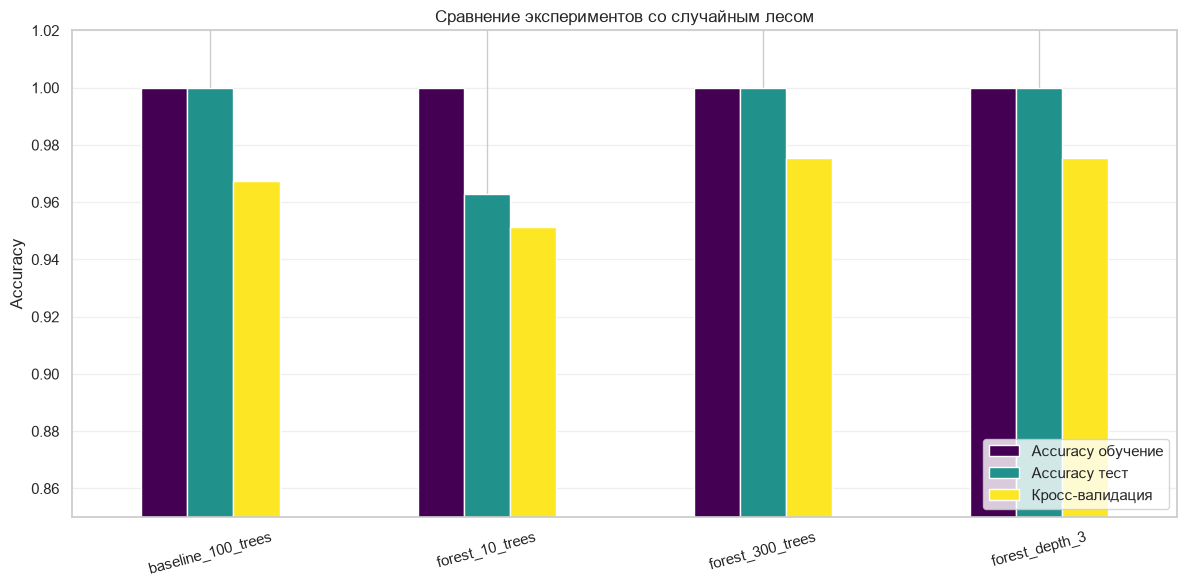

In [34]:
# Нарисуем сравнение экспериментов.
fig, ax = plt.subplots(figsize=(12, 6))

# Готовим данные: строки — названия запусков, столбцы — метрики.
plot_data = results_df.set_index("Запуск")[
    ["Accuracy обучение", "Accuracy тест", "Кросс-валидация"]
]

# Рисуем сгруппированную столбчатую диаграмму.
plot_data.plot(
    kind="bar",
    ax=ax,
    colormap="viridis",
    rot=15,
    ylim=(0.85, 1.02),  # все значения близки к 1, поэтому сужаем диапазон
)

ax.set_title("Сравнение экспериментов со случайным лесом")
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Что показало сравнение

* **10 деревьев** — качество уже высокое, но кросс-валидация даёт
  больший разброс. Малое число деревьев делает результат менее стабильным.
* **100 деревьев** — надёжный вариант: качество на уровне лучших,
  разброс небольшой.
* **300 деревьев** — прирост качества почти отсутствует.
  Это подтверждает график из пункта 5.3: после 50–100 деревьев
  кривая выходит на плато. Платить втрое большим временем обучения
  за доли процента качества не стоит.
* **Ограниченная глубина (max_depth=3)** — на тестовой выборке
  дала тот же идеальный результат (1.0), а кросс-валидация оказалась
  даже немного выше, чем у модели без ограничений: 0.975 против 0.967.
  То есть ограничение глубины здесь **не ухудшило**, а улучшило модель.
  Это важный результат: более простая модель оказалась надёжнее.

**Практический вывод:** для этой задачи разумный выбор — 100 деревьев
без ограничения глубины. Это баланс между качеством, стабильностью
и временем обучения.

## 8. Выводы

**Что сделано:**

1. Загружен и описан датасет Wine: 178 образцов, 13 химических признаков,
   3 сорта вина.
2. Проведён разведочный анализ: пропусков нет, дубликатов нет,
   зафиксированы выбросы почти во всех признаках. Показано,
   что здесь выбросы — не мусор, а информация о сорте.
3. Проверен баланс классов: 59, 71 и 48 образцов — классы
   несбалансированы, "глупая" модель даёт около 40 %.
4. Построены распределения в разрезе сортов. Выявлены четыре сильных
   признака: flavanoids, proline, color_intensity, od280/od315.
5. Построена матрица корреляции. Найдена сильная положительная связь
   flavanoids ↔ total_phenols (около +0.86) и отрицательная
   flavanoids ↔ nonflavanoid_phenols (около −0.54).
6. Обучен случайный лес из 100 деревьев.
7. Проведена кросс-валидация и исследовано влияние числа деревьев
   на качество: найдено плато после 50–100 деревьев.
8. Проанализирована важность признаков и уверенность предсказаний.
9. Обучены четыре варианта случайного леса и выполнено их сравнение.

**Ключевой результат:** случайный лес показал **абсолютную точность**:
все 54 образца тестовой выборки определены верно, ошибок нет.
Средняя уверенность модели — 0.89.

При этом кросс-валидация даёт более скромную цифру — около 0.97,
и это нормально. Она честнее: модель обучается и проверяется
по очереди на пяти разных частях данных, а не на одном удачном
разделении. Именно **кросс-валидация** — та метрика,
на которую стоит ориентироваться.

**Чему учит эта задача:**

* **Ансамбль сильнее одного дерева.** Усреднение ста деревьев
  даёт результат стабильнее и меньше подвержено переобучению,
  чем одиночное дерево.
* **Больше деревьев — не всегда лучше.** После 50–100 деревьев
  качество выходит на плато. Важно найти эту точку, а не гнаться
  за количеством.
* **Кросс-валидация честнее одного разделения.** Она показывает не одну
  цифру, а среднее и разброс — и это даёт понимание надёжности результата.
* **Важность признаков — сильный инструмент анализа.** Лес сам показывает,
  какие признаки действительно важны. При этом важно понимать:
  важность говорит о **силе участия**, но не о направлении влияния.
* **Уверенность модели нужно использовать.** Лес умеет сообщать,
  насколько он уверен. Сомнительные случаи можно передавать
  человеку на проверку — это стандартный приём в промышленных системах.
* **Выбросы — не всегда мусор.** В химических данных крупные значения
  как раз характеризуют разные сорта, и удалять их было бы ошибкой.

**Что можно улучшить:**

* провести **подбор гиперпараметров** — например, с помощью GridSearchCV
  перебрать комбинации n_estimators, max_depth и max_features;
* применить **отбор признаков** и оставить 5–6 главных:
  качество почти не упадёт, а модель упростится;
* попробовать **градиентный бустинг** (Gradient Boosting, XGBoost, LightGBM) —
  он часто даёт ещё более высокое качество на табличных данных;
* построить **границы принятия решений** по двум главным признакам,
  чтобы увидеть, как именно модель делит пространство между сортами;
* проверить модель на **внешнем датасете** — это единственный способ
  убедиться, что она обобщает, а не подстроилась под конкретные 178 образцов;
* помнить, что идеальная точность на одном разделении — это ещё не гарантия.
  Кросс-валидация около 0.97 говорит, что на новых данных
  стоит ожидать именно такого результата, а не 1.0.